# Embedding scikit-learn toy datasets

This notebook applies `SkeletalEmbedding` to several 2D toy distributions, including a custom open spiral. Labels are used only for coloring the plots; the graph fitting and embedding are unsupervised. The right-hand panels show the graph coordinates `(route_id, position)` returned by the model.

In [1]:
from pathlib import Path
import warnings
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import (
    make_blobs,
    make_circles,
    make_classification,
    make_gaussian_quantiles,
    make_moons,
)

working_dir = Path.cwd().resolve()
notebooks_dir = working_dir / 'notebooks' if (working_dir / 'notebooks' / '__init__.py').exists() else working_dir
project_root = notebooks_dir.parent
if not (project_root / 'src' / 'skeletalembedding').exists():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory')
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))
sys.path.insert(0, str(notebooks_dir))

from skeletalembedding import SkeletalEmbedding
from skeletalembedding.visualization.plots import plot_embedding_row

In [2]:
def make_spiral(n_samples=500, noise=0.045, turns=1.15, random_state=5):
    """Generate a noisy open spiral and a single plotting label."""
    rng = np.random.default_rng(random_state)
    theta = np.linspace(0.0, 2.0 * np.pi * turns, n_samples)
    radius = np.linspace(0.1, 1.0, n_samples)
    X = np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])
    labels = np.zeros(n_samples, dtype=int)
    permutation = rng.permutation(n_samples)
    X = X + rng.normal(scale=noise, size=X.shape)
    return X[permutation], labels[permutation]


toy_datasets = {}

toy_datasets['moons'] = make_moons(n_samples=500, noise=0.07, random_state=0)
toy_datasets['circles'] = make_circles(n_samples=500, factor=0.42, noise=0.045, random_state=1)
toy_datasets['spiral'] = make_spiral(n_samples=500, noise=0.045, random_state=5)
toy_datasets['blobs'] = make_blobs(
    n_samples=500,
    centers=[(-1.2, -0.8), (0.0, 1.0), (1.2, -0.4)],
    cluster_std=[0.22, 0.28, 0.20],
    random_state=2,
)
toy_datasets['classification'] = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.25,
    flip_y=0.04,
    random_state=3,
)
toy_datasets['gaussian-quantiles'] = make_gaussian_quantiles(
    n_samples=500,
    n_features=2,
    n_classes=3,
    random_state=4,
)

toy_datasets.keys()

dict_keys(['moons', 'circles', 'spiral', 'blobs', 'classification', 'gaussian-quantiles'])

In [3]:
models = {}
embeddings = {}
summary_rows = []

for index, (name, (X, labels)) in enumerate(toy_datasets.items()):
    initialization = 'legacy_coarsen' if name == 'spiral' else 'skeletal'
    model = SkeletalEmbedding(
        initialization=initialization,
        n_centroids=45,
        persistence_threshold=4.0,
        spline_smoothing=0.1,
        max_cycles=4,
        random_state=10 + index,
        standardize=True,
        merge_junction_distance=None,
        prune_short_branches=True,
        prune_branch_factor=0.5,
        persistence_max_points=60,
        spline_samples_per_node=12,
        linear_structure_tolerance=0.12,
        topology_neighbors=6,
        detect_cycles=True,
        detect_junctions=True,
        junction_scales=6,
        junction_inner_fraction=0.25,
        junction_confidence=0.7,
        use_local_pca=True,
        local_pca_neighbors=20,
        max_branch_angle_degrees=45.0,
        use_effective_resistance=False,
        use_electrical_flow=False,
        use_kron_reduction=False,
        routing_length_weight=1.0,
        routing_tangent_weight=1.0,
        routing_density_weight=0.5,
        routing_resistance_weight=0.0,
        routing_current_weight=0.0,
        use_tangent_boundary_conditions=True,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore',
            message='Topological landmark constraints could not all be realized by the routing substrate\\.',
            category=RuntimeWarning,
        )
        warnings.filterwarnings(
            'ignore',
            message='The sparse landmark graph could not realize all requested cycles.*',
            category=RuntimeWarning,
        )
        result = model.fit_transform(X)
    models[name] = model
    embeddings[name] = result
    summary_rows.append({
        'dataset': name,
        'cycles': model.realized_cycle_count_,
        'junctions': len(model.junctions_),
        'endpoints': len(model.endpoints_),
        'spline_chains': len(model.splines_),
        'ribs': len(model.rib_paths_),
        'median_residual': float(np.median(result.residual_norm)),
    })

summary = pd.DataFrame(summary_rows)
summary

,dataset,cycles,junctions,endpoints,spline_chains,ribs,median_residual
0,moons,0,0,4,2,0,0.080807
1,circles,2,0,0,2,0,0.060906
2,spiral,0,0,2,1,0,0.070687
3,blobs,0,0,6,3,0,0.234040
4,classification,0,3,8,6,0,0.092463
5,gaussian-quantiles,0,1,11,11,0,0.177212


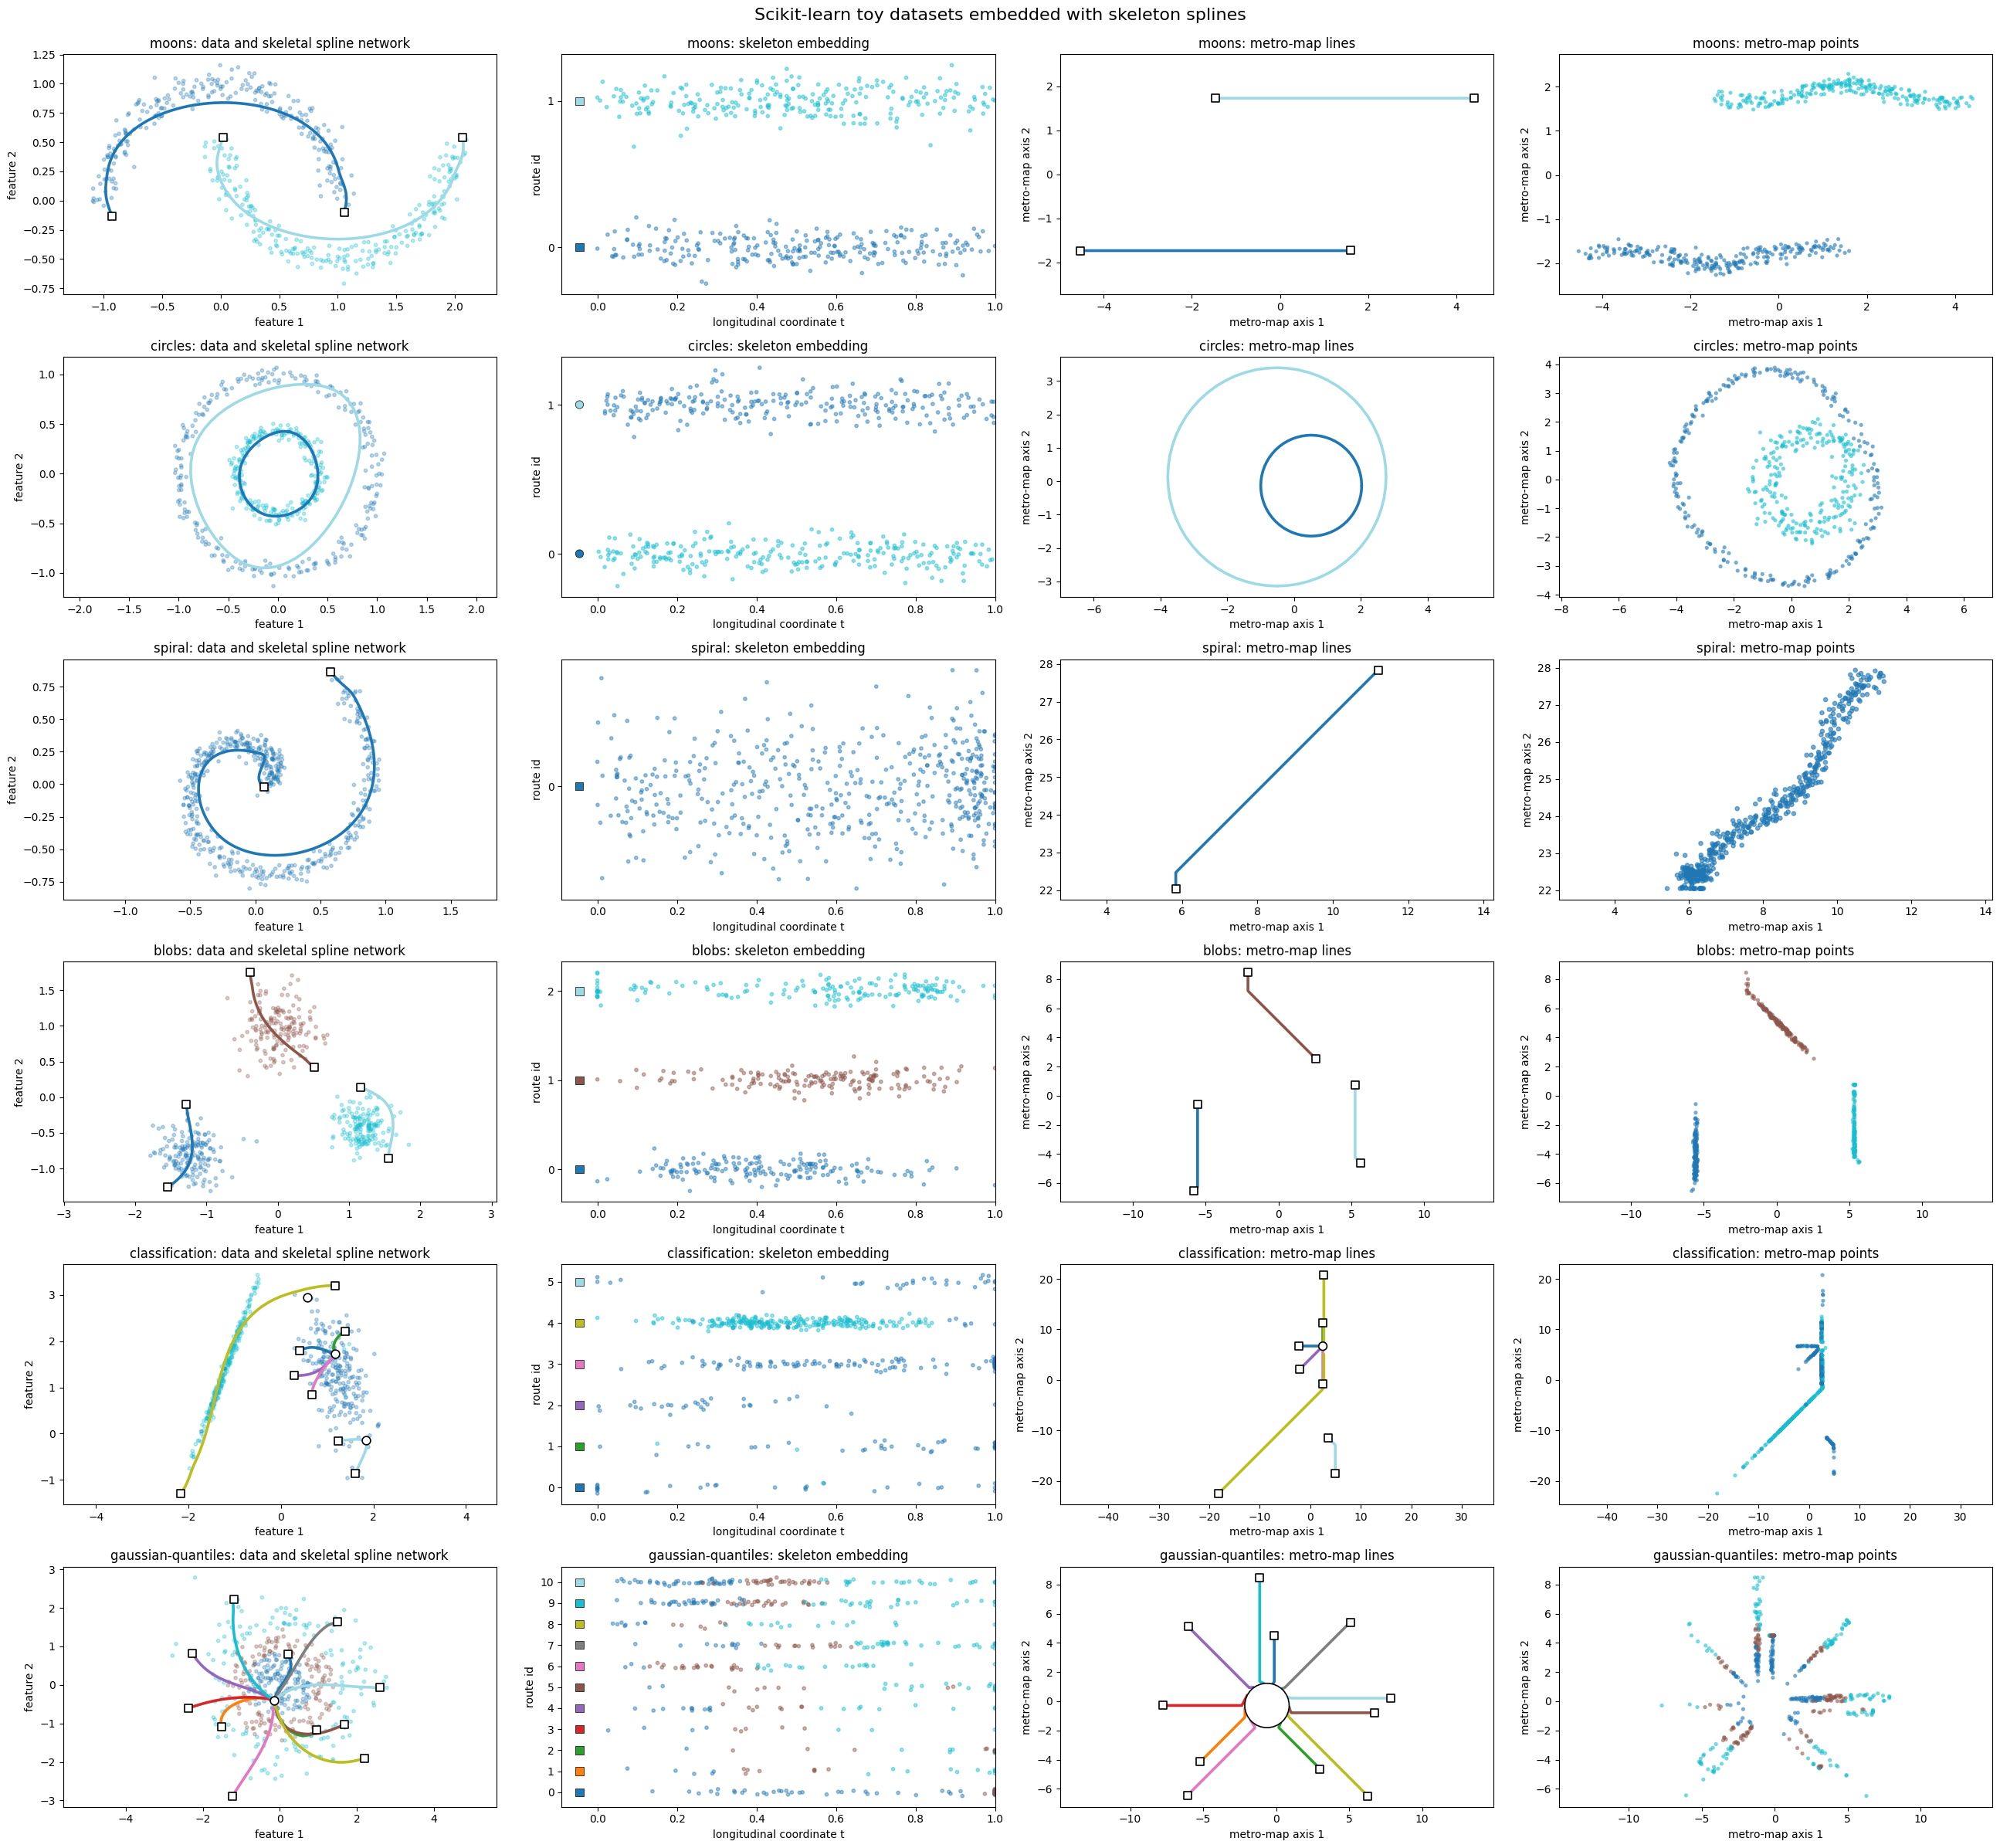

In [4]:
fig, axes = plt.subplots(len(toy_datasets), 4, figsize=(26, 4 * len(toy_datasets)))
if len(toy_datasets) == 1:
    axes = axes[None, :]

for row, (name, (X, labels)) in enumerate(toy_datasets.items()):
    model = models[name]
    result = embeddings[name]
    plot_embedding_row(
        axes=axes[row],
        points=X,
        labels=labels,
        model=model,
        result=result,
        projected_title=f'{name}: data and skeletal spline network',
        graph_title=f'{name}: skeleton embedding',
        metro_lines_title=f'{name}: metro-map lines',
        metro_points_title=f'{name}: metro-map points',
        reducer=None,
        colors=None,
        jitter_seed=row,
        layout=None,
        show_metro_nodes=False,
        classification_metrics=None,
        route_metrics=None,
        metro_residual_width=0.08,
    )

fig.suptitle('Scikit-learn toy datasets embedded with skeleton splines', fontsize=16, y=0.995)
fig.tight_layout()
figure_dir = project_root / 'notebooks' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / 'sklearn_toy_datasets.png', dpi=160, bbox_inches='tight')
plt.show()

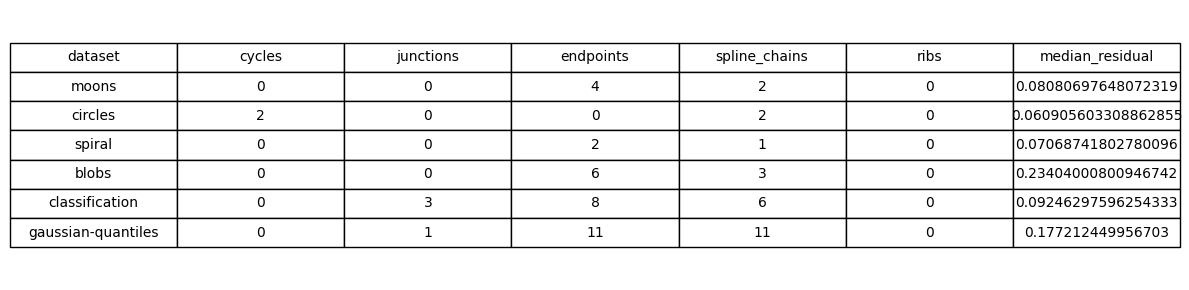

In [5]:
columns = summary.columns.tolist()
table_values = summary[columns].values.tolist()
summary_fig, summary_axis = plt.subplots(figsize=(12, 3.0))
summary_axis.axis('off')
table = summary_axis.table(cellText=table_values, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
summary_fig.tight_layout()
summary_fig.savefig(figure_dir / 'sklearn_toy_summary.png', dpi=160, bbox_inches='tight')
plt.show()

## Interactive toy-dataset exploration

Select one dataset, adjust the graph-fitting parameters, and refit its four-panel visualization.

In [6]:
from skeletalembedding.visualization.workflows.interactive import display_interactive_viewer

display_interactive_viewer(toy_datasets, default_reducer="native")